# Avance de Proyecto: Análisis de Perfiles de Inversión
### Ricardo Delgadillo Diaz
Identificar patrones y agrupaciones de activos financieros utilizando técnicas de aprendizaje no supervisado (PCA y K-means) buscando tener mejor rendimiento a comparacion de la clasificaciones tradicionlaes o preestablecidas.

#Adquisición y Limpieza de Datos
Se extraen series históricas de precios de cierre ajustados desde Yahoo Finance utilizando la librería yfinance.

- Unidad de análisis: 7 activos que incluyen acciones tecnológicas, energía y commodities.

- Tratamiento: Se eliminan valores nulos y se transforman los precios en retornos porcentuales diarios para estandarizar la escala de análisis.

In [1]:
import yfinance as yf
import pandas as pd

# 1. Lista de activos (tickers)
tickers = ['AAPL', 'MSFT', 'GOOGL', 'XOM', 'CVX', 'GC=F', '^GSPC']

# 2. Descarga de datos
# Agregamos auto_adjust=False para que no haya conflictos con el cierre ajustado
raw_data = yf.download(tickers, start="2023-01-01", end="2026-04-01", auto_adjust=False)

# 3. Solución al KeyError: Accedemos al cierre ajustado de forma segura
if 'Adj Close' in raw_data.columns:
    data = raw_data['Adj Close']
else:
    # A veces la librería lo descarga como 'adj close' (minúsculas)
    data = raw_data.xs('Adj Close', axis=1, level=0)

# 4. Limpieza: Eliminar nulos y calcular retornos (esto sirve para tu EDA)
data_clean = data.dropna()
returns = data_clean.pct_change().dropna() # Retornos diarios

# 5. Guardar y verificar
data_clean.to_csv('dataset_inversiones.csv')
print(f"Rango de fechas: {data_clean.index.min()} a {data_clean.index.max()}")
print(f"Número de activos: {data_clean.shape[1]}")
print(f"Total de registros: {data_clean.shape[0]}")
print("Primeras filas del dataset:")
print(data_clean.head())

[*********************100%***********************]  7 of 7 completed

Rango de fechas: 2023-01-03 00:00:00 a 2026-03-31 00:00:00
Número de activos: 7
Total de registros: 813
Primeras filas del dataset:
Ticker            AAPL         CVX         GC=F      GOOGL        MSFT  \
Date                                                                     
2023-01-03  123.096031  151.901291  1839.699951  88.389473  233.452805   
2023-01-04  124.365662  150.286179  1852.800049  87.357994  223.240814   
2023-01-05  123.046806  152.992615  1834.800049  85.493401  216.624451   
2023-01-06  127.574211  154.145004  1864.199951  86.624046  219.177460   
2023-01-09  128.095886  152.940201  1872.699951  87.298477  221.311462   

Ticker            XOM        ^GSPC  
Date                                
2023-01-03  95.434204  3824.139893  
2023-01-04  95.711960  3852.969971  
2023-01-05  97.853439  3808.100098  
2023-01-06  99.036163  3895.080078  
2023-01-09  97.190376  3892.090088  


# Reducción de Dimensionalidad (PCA)
Dado que los datos financieros presentan alta correlación, aplicamos Análisis de Componentes Principales (PCA) previo al clustering.

- Escalamiento: Se usa StandardScaler para que la magnitud de los precios (ej. Oro vs Apple) no sesgue el algoritmo.

- Decisión Técnica: Reducimos el espacio a 2 componentes para facilitar la visualización de estructuras ocultas de riesgo.

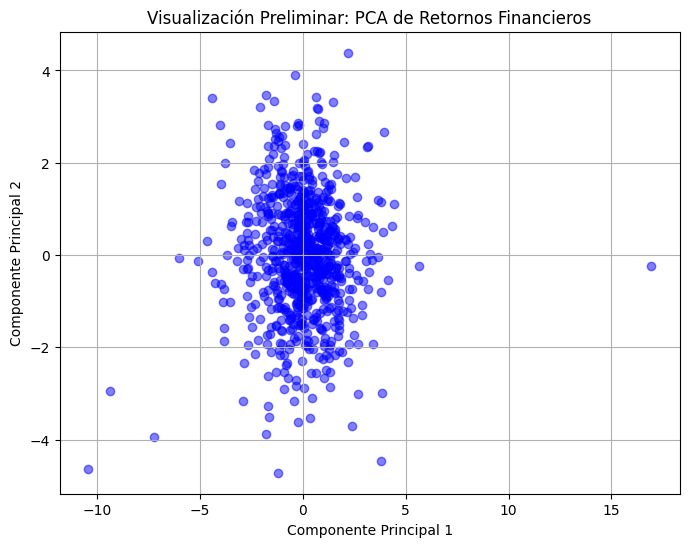

Varianza explicada por los 2 componentes: 0.6498956380871289


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Calcular retornos logarítmicos
# Esto estabiliza la varianza y es estándar en ML financiero
returns = data_clean.pct_change().dropna()

# 2. Escalamiento de datos (StandardScaler)
# Esto asegura que el Oro (GC=F) y Apple tengan el mismo peso inicial
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(returns)

# 3. Implementación preliminar de PCA (Reducción de dimensionalidad)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_returns)

# 4. Visualización inicial
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], alpha=0.5, c='blue')
plt.title('Visualización Preliminar: PCA de Retornos Financieros')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

print("Varianza explicada por los 2 componentes:", pca.explained_variance_ratio_.sum())

#Segmentación mediante Clustering (K-means)
Utilizamos el algoritmo K-means para agrupar los días de mercado en perfiles de inversión específicos.

- Criterio de Optimización: Se busca minimizar la inercia intracluster para encontrar grupos compactos y bien diferenciados.

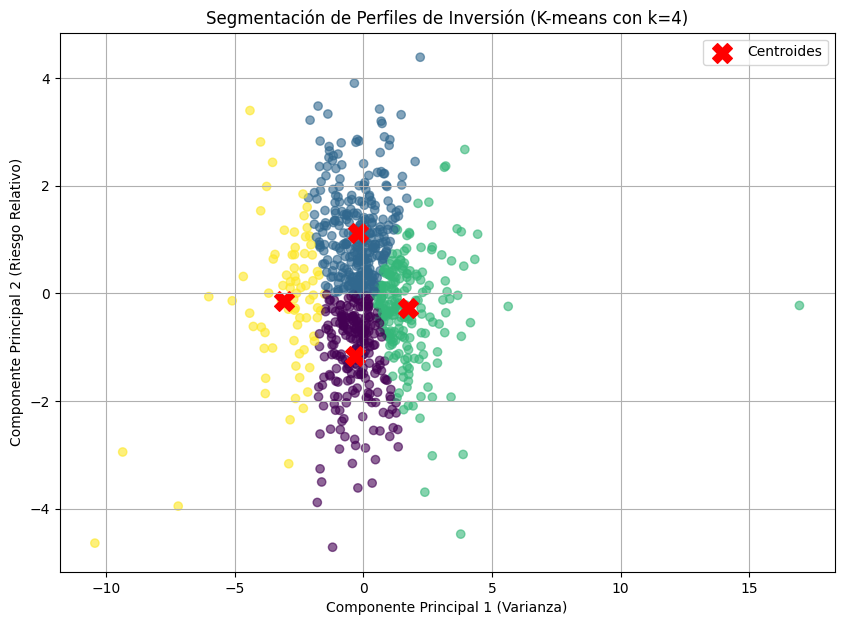

Inercia del modelo (Criterio de optimización): 1589.8483149758308


In [3]:
from sklearn.cluster import KMeans

# 1. Aplicar K-means
# Usamos los datos del PCA para que el clustering sea más eficiente
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_data)

# 2. Visualización de los Clusters
plt.figure(figsize=(10, 7))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroides')

plt.title(f'Segmentación de Perfiles de Inversión (K-means con k={n_clusters})')
plt.xlabel('Componente Principal 1 (Varianza)')
plt.ylabel('Componente Principal 2 (Riesgo Relativo)')
plt.legend()
plt.grid(True)
plt.show()

print("Inercia del modelo (Criterio de optimización):", kmeans.inertia_)

# Análisis Preliminar de Resultados
La visualización muestra una segmentación clara en 4 regímenes de mercado.

- Limitación detectada: Se observa una alta sensibilidad a outliers que alejan los centroides del comportamiento promedio.

- Ruta alternativa: En la fase final se evaluará el uso de Modelos de Mezcla Gaussiana (GMM) para manejar mejor el traslape de datos en zonas de baja volatilidad.

#Selección Óptima de Clusters (K)
Se aplicó el Método del Codo para determinar el numero optimo de clusters, el cual analiza la evolución de la inercia (la suma de los cuadrados de las distancias internas de los clusters) a medida que aumenta el número de $k$.
- Análisis de la gráfica: Se observa que el descenso más significativo de la inercia ocurre entre $k=2$ y $k=4$.
- Decisión Técnica: Se selecciona $k=4$ como el punto de equilibrio donde la complejidad del modelo es baja pero la ganancia en explicación de la estructura de los datos sigue siendo relevante.
- Justificación: Superar este número de clusters podría llevar a un sobreajuste.

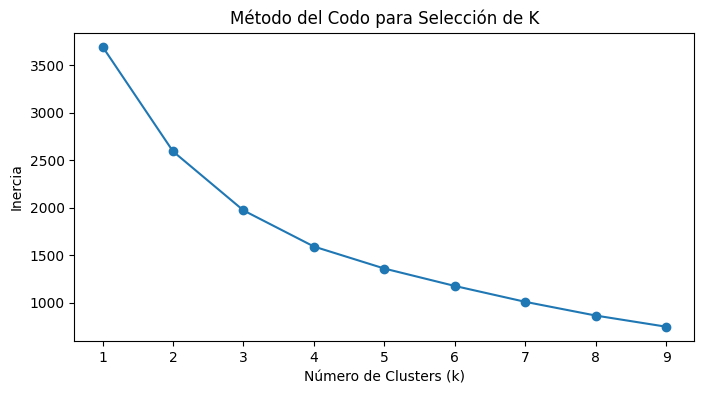

In [4]:
# Justificación del número de clusters (Método del Codo)
inercias = []
for k in range(1, 10):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(pca_data)
    inercias.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 10), inercias, marker='o')
plt.title('Método del Codo para Selección de K')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.show()